# 01 - SpeechXAI Single Example

This notebook classifies one IEMOCAP utterance with the SUPERB wav2vec 2.0 emotion model used by Pastor et al., obtains word timestamps with SpeechXAI's WhisperX transcription function, and passes those same timestamp objects into SpeechXAI's leave-one-out explainer. It then plots the waveform with lexical word boundaries, the effective SpeechXAI silence masks, and word attribution scores. Finally, it evaluates top-k SpeechXAI words against random regions with the same total masked duration. No result files are generated.

The next cell imports only the general numerical, plotting, and project utilities used throughout the notebook, then resolves the experiment configuration.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from speech_xai_project import audio, config, intervals, masking, model

project_config = config.load_config(PROJECT_ROOT / 'configs' / 'default.yaml')
IEMOCAP_ROOT = config.project_path(project_config['paths']['iemocap_root'])
METADATA_CSV = config.project_path(project_config['paths']['metadata_csv'])
MODEL_SOURCE = project_config['model']['source']
MODEL_CACHE_DIR = config.project_path(project_config['model']['cache_dir'])
TARGET_SAMPLE_RATE = project_config['model']['sample_rate']
TOP_K_VALUES = project_config['evaluation']['speechxai_top_k_values']
RANDOM_TRIALS = project_config['evaluation']['random_trials']
RANDOM_SEED = project_config['evaluation']['random_seed']
speechxai_config = project_config['speechxai']

AUDIO_ID = 'Ses01F_impro01_F005'

The next cell loads the selected IEMOCAP waveform and reports its dataset emotion label and duration.

In [2]:
metadata_table = audio.load_metadata_or_discover(METADATA_CSV, IEMOCAP_ROOT)
selected_rows = metadata_table[metadata_table['audio_id'] == AUDIO_ID]
if selected_rows.empty:
    raise ValueError(f'Audio ID {AUDIO_ID} was not found in {METADATA_CSV}.')

audio_row = selected_rows.iloc[0]
audio_path = Path(audio_row.audio_path)
waveform, sample_rate = audio.load_waveform(audio_path, TARGET_SAMPLE_RATE)
audio_duration = audio.duration_seconds(waveform, sample_rate)

print('Audio ID:', AUDIO_ID)
print('IEMOCAP emotion:', audio_row.true_label)
print('Duration:', round(audio_duration, 3), 'seconds')

Audio ID: Ses01F_impro01_F005
IEMOCAP emotion: neu
Duration: 4.03 seconds


The next cell runs the original audio through the Pastor/SUPERB emotion classifier and fixes its predicted class as the attribution and evaluation target.

In [3]:
classifier = model.load_classifier(MODEL_SOURCE, MODEL_CACHE_DIR)
original_prediction = model.classify_waveform(classifier, waveform)
target_index = original_prediction.predicted_index
target_label = original_prediction.predicted_label
original_target_confidence = original_prediction.predicted_confidence

print('Predicted emotion:', target_label)
print('Predicted confidence:', round(original_target_confidence, 6))
print('Confidence vector:', original_prediction.probabilities.numpy())

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Predicted emotion: ang
Predicted confidence: 0.878075
Confidence vector: [0.06385588 0.04089139 0.8780751  0.01717767]


## How SpeechXAI obtains word timestamps

SpeechXAI delegates timestamp extraction to WhisperX through `transcribe_audio`. The process has two distinct inference stages:

1. **Automatic speech recognition:** Whisper `large-v2` decodes the waveform into text and coarse speech segments.
2. **Forced alignment:** WhisperX loads a language-specific wav2vec 2.0 alignment model and aligns the recognized text against acoustic frames. This produces a dictionary for each aligned word containing `word`, `start`, `end`, and usually `score`.

The alignment score describes confidence in the word-to-audio alignment. It is useful for identifying questionable boundaries, but it is not an emotion attribution score. SpeechXAI discards words for which WhisperX cannot produce a start time.

The next cell imports the upstream library at the point where timestamp functionality becomes necessary. The local checkout is exposed as the `speechxai` package without importing its top-level API, because that API eagerly imports optional explainers unrelated to this notebook.

In [4]:
import os
import types

import torch
import torchaudio

SPEECHXAI_ROOT = config.project_path(speechxai_config['repository_dir'])
if not SPEECHXAI_ROOT.exists():
    raise FileNotFoundError(f'SpeechXAI repository not found at {SPEECHXAI_ROOT}.')

# WhisperX uses FFmpeg to decode audio. The project keeps a local binary outside Git.
FFMPEG_DIR = PROJECT_ROOT / 'third_party' / 'ffmpeg'
os.environ['PATH'] = str(FFMPEG_DIR) + os.pathsep + os.environ.get('PATH', '')

# WhisperX 3.3 and pyannote still reference aliases removed by newer torchaudio.
if not hasattr(torchaudio, 'AudioMetaData'):
    class AudioMetaData:
        pass
    torchaudio.AudioMetaData = AudioMetaData

torchaudio_compatibility = {
    'list_audio_backends': lambda: ['soundfile'],
    'get_audio_backend': lambda: 'soundfile',
    'set_audio_backend': lambda backend: None,
}
for name, implementation in torchaudio_compatibility.items():
    if not hasattr(torchaudio, name):
        setattr(torchaudio, name, implementation)

# Register the checkout as a lightweight namespace package. This lets Python import
# the required SpeechXAI module without executing speechxai/__init__.py.
speechxai_package = types.ModuleType('speechxai')
speechxai_package.__path__ = [str(SPEECHXAI_ROOT / 'speechxai')]
sys.modules['speechxai'] = speechxai_package

from speechxai.explainers.utils_removal import transcribe_audio

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\ctranslate2\__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


The next cell runs SpeechXAI's timestamp pipeline exactly once. Its returned `word_segments` object is preserved and later passed unchanged to the explainer, preventing a second transcription from producing a different word sequence or slightly different boundaries.

In [5]:
compute_type = (
    speechxai_config['cuda_compute_type']
    if classifier.device.type == 'cuda'
    else speechxai_config['cpu_compute_type']
)

# WhisperX 3.3 loads a published pyannote VAD checkpoint serialized before
# PyTorch changed torch.load to weights_only=True. Limit the compatibility
# override to this trusted model-loading call and restore torch.load afterward.
original_torch_load = torch.load
def trusted_legacy_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_torch_load(*args, **kwargs)

torch.load = trusted_legacy_torch_load
try:
    whisper_text, word_segments = transcribe_audio(
        audio_path=str(audio_path),
        device=classifier.device.type,
        batch_size=speechxai_config['batch_size'],
        compute_type=compute_type,
        language=speechxai_config['language'],
        model_name_whisper=speechxai_config['whisper_model'],
    )
finally:
    torch.load = original_torch_load

if not word_segments:
    raise ValueError('SpeechXAI/WhisperX returned no aligned words for the selected audio.')

# Convert the library dictionaries into an inspection table while retaining the
# original word_segments list for SpeechXAI. The two representations must not drift.
timestamp_table = pd.DataFrame({
    'word': [segment['word'] for segment in word_segments],
    'start': [float(segment['start']) for segment in word_segments],
    'end': [float(segment['end']) for segment in word_segments],
    'transcription_score': [float(segment.get('score', np.nan)) for segment in word_segments],
})

# Fail early when alignment metadata cannot define valid regions on this waveform.
if not (timestamp_table['start'] >= 0).all():
    raise AssertionError('WhisperX returned a negative word start time.')
if not (timestamp_table['end'] > timestamp_table['start']).all():
    raise AssertionError('WhisperX returned an invalid word interval.')
if not timestamp_table['start'].is_monotonic_increasing:
    raise AssertionError('WhisperX word intervals are not chronologically ordered.')
if timestamp_table['end'].max() > audio_duration + 1 / sample_rate:
    raise AssertionError('WhisperX returned a word boundary beyond the audio duration.')

print('WhisperX transcript:', whisper_text.strip())
display(timestamp_table)

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\inspect.py:1007: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\whisperx\assets\pytorch_model.bin`


WhisperX transcript: Well, what's the problem? Let me change it.


,word,start,end,transcription_score
0,"Well,",0.594,0.796,0.880
1,what's,1.057,1.802,0.851
2,the,1.842,1.923,0.760
3,problem?,1.943,2.366,0.854
4,Let,2.466,2.587,0.980
5,me,2.627,2.708,0.846
6,change,2.748,3.010,0.839
7,it.,3.091,3.131,0.862


## From aligned words to attribution scores

The next cell imports SpeechXAI's emotion-model adapter and leave-one-out explainer. `ModelHelperER` converts pydub audio arrays into the feature-extractor format expected by the SUPERB classifier. `LOOSpeechExplainer` creates one perturbed audio per word, replaces that word region with silence, and defines importance as the original target-class probability minus the perturbed probability.

The exact `word_segments` returned above are supplied through `words_trascript`. SpeechXAI therefore skips internal retranscription and preserves index correspondence among words, timestamps, and scores.

### SpeechXAI source files responsible for removal

The removal behavior used here can be inspected directly in the local SpeechXAI checkout:

- [`loo_speech_explainer.py`](../third_party/SpeechXAI/speechxai/explainers/loo_speech_explainer.py) implements the leave-one-out workflow. `LOOSpeechExplainer.remove_words` iterates through the aligned words and calls `remove_word` once for each word; `compute_explanation` then compares the original and perturbed class probabilities.
- [`utils_removal.py`](../third_party/SpeechXAI/speechxai/explainers/utils_removal.py) implements the waveform modification. `remove_word` is used to calculate an individual LOO attribution. It converts WhisperX seconds to pydub milliseconds, expands the interval by 100 ms before and 40 ms after, and replaces that duration with silence when `removal_type="silence"`.
- The same `utils_removal.py` file also defines `remove_specified_words`, which applies removal to a collection of selected words and is used by SpeechXAI's faithfulness evaluators.
- [`faithfulness_measures_speech.py`](../third_party/SpeechXAI/speechxai/evaluators/faithfulness_measures_speech.py) selects words from an explanation and passes them to `remove_specified_words` for comprehensiveness and sufficiency evaluation.

The 100/40 ms expansion is therefore behavior of the released Python implementation. The paper describes zeroing WhisperX-derived word segments but does not document these padding constants.

In [6]:
from pydub import AudioSegment

# These are the two helpers imported by the upstream explainer from speechxai.utils.
# Defining only this narrow interface avoids importing optional dataset utilities.
def pydub_to_np(audio_segment):
    samples = np.array(audio_segment.get_array_of_samples(), dtype=np.float32)
    samples = samples.reshape((-1, audio_segment.channels))
    scale = 1 << (8 * audio_segment.sample_width - 1)
    return samples / scale, audio_segment.frame_rate

def print_log(*args):
    print(args)

speechxai_utils = types.ModuleType('speechxai.utils')
speechxai_utils.pydub_to_np = pydub_to_np
speechxai_utils.print_log = print_log
sys.modules['speechxai.utils'] = speechxai_utils

from speechxai.explainers.loo_speech_explainer import LOOSpeechExplainer
from speechxai.model_helpers.model_helper_er import ModelHelperER

model_helper = ModelHelperER(
    classifier.network,
    classifier.feature_extractor,
    classifier.device,
    language=speechxai_config['language'],
)
padding_before = float(speechxai_config['mask_padding_before_seconds'])
padding_after = float(speechxai_config['mask_padding_after_seconds'])
if min(float(segment['start']) for segment in word_segments) < padding_before:
    raise ValueError(
        'SpeechXAI remove_word uses an unclamped 100 ms pre-word pydub slice. '
        'This audio contains a word too close to time zero for a trustworthy attribution.'
    )

speechxai_explainer = LOOSpeechExplainer(model_helper)
speechxai_audio = pydub_to_np(AudioSegment.from_wav(str(audio_path)))[0]
speechxai_original_probabilities = model_helper.predict([speechxai_audio])[0]
speechxai_target_index = int(np.argmax(speechxai_original_probabilities))
if speechxai_target_index != target_index:
    raise AssertionError('SpeechXAI and project audio-loading paths predict different classes.')
if not np.allclose(
    speechxai_original_probabilities,
    original_prediction.probabilities.numpy(),
    atol=1e-5,
):
    raise AssertionError('SpeechXAI and project audio-loading paths produce different probabilities.')

explanation = speechxai_explainer.compute_explanation(
    audio_path=str(audio_path),
    target_class=target_index,
    removal_type='silence',
    words_trascript=word_segments,
)

scores = np.asarray(explanation.scores, dtype=float).reshape(-1)
segment_words = [segment['word'] for segment in word_segments]
if explanation.features != segment_words or len(scores) != len(word_segments):
    raise AssertionError('SpeechXAI words, timestamps, and attribution scores are not aligned.')

word_attributions = pd.DataFrame({
    'audio_id': AUDIO_ID,
    'word': segment_words,
    'start': [float(segment['start']) for segment in word_segments],
    'end': [float(segment['end']) for segment in word_segments],
    'masked_start': [max(0.0, float(segment['start']) - padding_before) for segment in word_segments],
    'masked_end': [min(audio_duration, float(segment['end']) + padding_after) for segment in word_segments],
    'transcription_score': [float(segment.get('score', np.nan)) for segment in word_segments],
    'score': scores,
})

display(word_attributions.sort_values('score', ascending=False).reset_index(drop=True))

,audio_id,word,start,end,masked_start,masked_end,transcription_score,score
0,Ses01F_impro01_F005,what's,1.057,1.802,0.957,1.842,0.851,0.421790
1,Ses01F_impro01_F005,Let,2.466,2.587,2.366,2.627,0.980,0.119292
2,Ses01F_impro01_F005,problem?,1.943,2.366,1.843,2.406,0.854,0.093303
3,Ses01F_impro01_F005,the,1.842,1.923,1.742,1.963,0.760,0.072442
4,Ses01F_impro01_F005,change,2.748,3.010,2.648,3.050,0.839,-0.004034
5,Ses01F_impro01_F005,me,2.627,2.708,2.527,2.748,0.846,-0.007125
6,Ses01F_impro01_F005,it.,3.091,3.131,2.991,3.171,0.862,-0.043016
7,Ses01F_impro01_F005,"Well,",0.594,0.796,0.494,0.836,0.880,-0.083566


The next cell plots the waveform, real WhisperX word locations, effective SpeechXAI mask spans, and signed word attribution scores on the same time axis.

C:\Users\mateu\AppData\Local\Temp\ipykernel_37844\1068125011.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


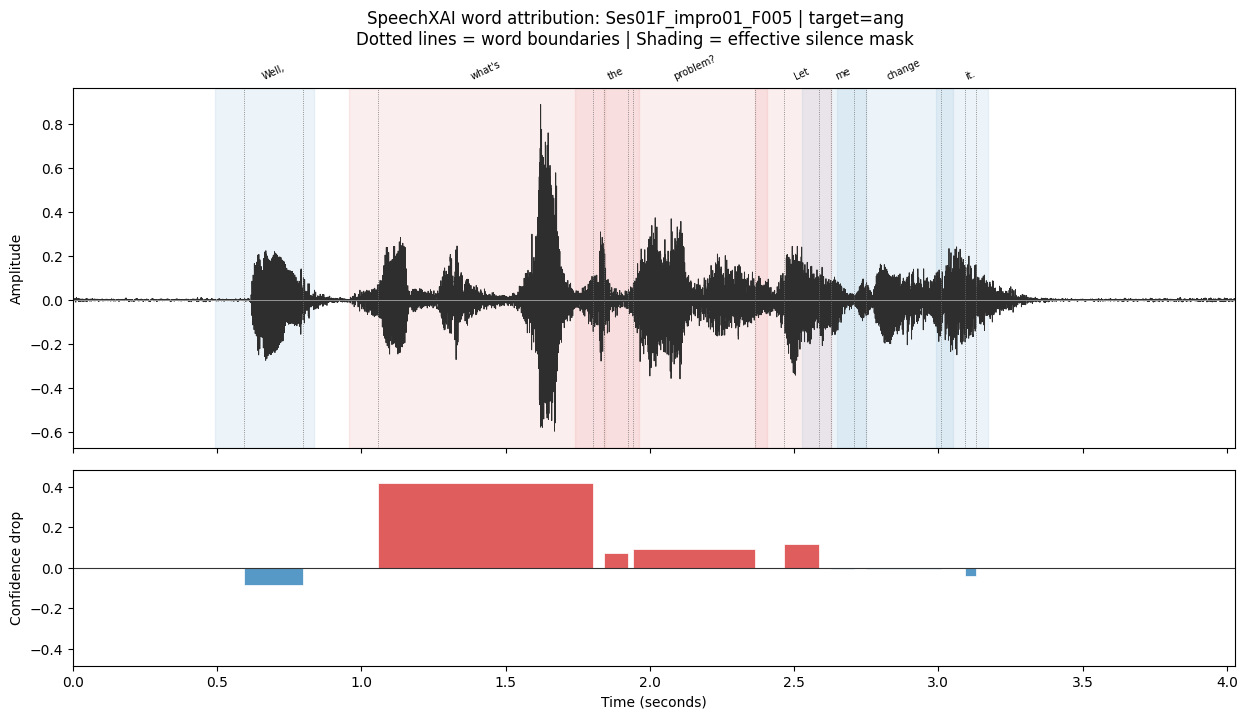

In [7]:
waveform_values = waveform.squeeze(0).cpu().numpy()
time_axis = np.arange(len(waveform_values)) / sample_rate

figure, (waveform_axis, score_axis) = plt.subplots(
    2,
    1,
    figsize=(15, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2], "hspace": 0.08},
)

# Waveform
waveform_axis.plot(time_axis, waveform_values, color="0.18", linewidth=0.65)
waveform_axis.axhline(0.0, color="0.65", linewidth=0.6)

# Word spans + boundaries + labels
for row in word_attributions.itertuples(index=False):
    color = "tab:red" if row.score >= 0 else "tab:blue"

    waveform_axis.axvspan(
        row.masked_start,
        row.masked_end,
        color=color,
        alpha=0.08,
    )

    waveform_axis.axvline(
        row.start,
        color="0.45",
        linewidth=0.6,
        linestyle=":",
    )

    waveform_axis.axvline(
        row.end,
        color="0.45",
        linewidth=0.6,
        linestyle=":",
    )

    waveform_axis.text(
        (row.start + row.end) / 2,
        1.02,
        row.word,
        transform=waveform_axis.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=25,
    )

# Attribution bars
centers = (word_attributions["start"] + word_attributions["end"]) / 2
widths = word_attributions["end"] - word_attributions["start"]
colors = np.where(word_attributions["score"] >= 0, "tab:red", "tab:blue")

score_axis.bar(
    centers,
    word_attributions["score"],
    width=widths,
    color=colors,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.7,
)

score_axis.axhline(0.0, color="0.2", linewidth=0.8)

# Axes
score_axis.set_xlim(0.0, audio_duration)

score_limit = max(float(word_attributions["score"].abs().max()) * 1.15, 0.01)
score_axis.set_ylim(-score_limit, score_limit)

score_axis.set_xlabel("Time (seconds)")
score_axis.set_ylabel("Confidence drop")
waveform_axis.set_ylabel("Amplitude")

# Better title: split into two lines and use the figure title
figure.suptitle(
    f"SpeechXAI word attribution: {AUDIO_ID} | target={target_label}\n"
    "Dotted lines = word boundaries | Shading = effective silence mask",
    fontsize=12,
    y=0.985,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Use the player below to listen to the original audio represented by the waveform and word-attribution plot above.

In [8]:
from IPython.display import Audio, display

display(Audio(filename=str(audio_path)))

## Where SpeechXAI removal regions overlap

SpeechXAI expands every lexical word interval by 100 ms before and 40 ms after. Neighboring expanded intervals can therefore cover the same samples. The next plot gives each word its own mask lane and computes the exact number of active masks at every waveform sample. Red background regions indicate overlap depth greater than one.

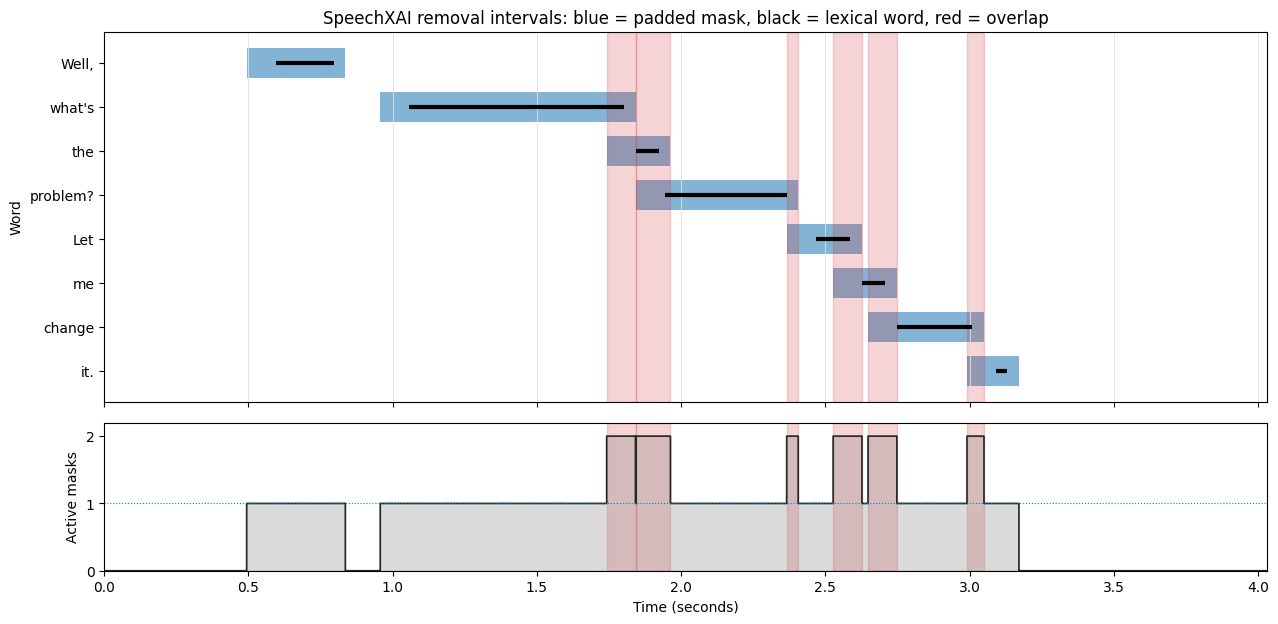

Overlapping regions: 6
Maximum simultaneous masks: 2


In [9]:
overlap_depth = np.zeros(waveform.shape[-1], dtype=np.int16)
mask_sample_bounds = []

for row in word_attributions.itertuples(index=False):
    start_sample = max(0, int(round(row.masked_start * sample_rate)))
    end_sample = min(waveform.shape[-1], int(round(row.masked_end * sample_rate)))
    overlap_depth[start_sample:end_sample] += 1
    mask_sample_bounds.append((start_sample, end_sample))

# Convert each contiguous depth >= 2 run back to seconds for exact highlighting.
overlap_samples = overlap_depth >= 2
overlap_changes = np.diff(np.pad(overlap_samples.astype(np.int8), (1, 1)))
overlap_starts = np.flatnonzero(overlap_changes == 1)
overlap_ends = np.flatnonzero(overlap_changes == -1)
overlap_intervals = [
    (start / sample_rate, end / sample_rate)
    for start, end in zip(overlap_starts, overlap_ends)
]

figure, (mask_axis, depth_axis) = plt.subplots(
    2,
    1,
    figsize=(15, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.2], "hspace": 0.08},
)

for lane, (row, (start_sample, end_sample)) in enumerate(
    zip(word_attributions.itertuples(index=False), mask_sample_bounds)
):
    mask_start = start_sample / sample_rate
    mask_duration = (end_sample - start_sample) / sample_rate
    mask_axis.broken_barh(
        [(mask_start, mask_duration)],
        (lane - 0.34, 0.68),
        facecolors="tab:blue",
        alpha=0.55,
    )
    mask_axis.plot(
        [row.start, row.end],
        [lane, lane],
        color="black",
        linewidth=3,
        solid_capstyle="butt",
    )

for overlap_start, overlap_end in overlap_intervals:
    mask_axis.axvspan(overlap_start, overlap_end, color="tab:red", alpha=0.20)
    depth_axis.axvspan(overlap_start, overlap_end, color="tab:red", alpha=0.20)

mask_axis.set_yticks(np.arange(len(word_attributions)))
mask_axis.set_yticklabels(word_attributions["word"])
mask_axis.set_ylim(-0.7, len(word_attributions) - 0.3)
mask_axis.invert_yaxis()
mask_axis.set_ylabel("Word")
mask_axis.set_title(
    "SpeechXAI removal intervals: blue = padded mask, black = lexical word, red = overlap"
)
mask_axis.grid(axis="x", color="0.88", linewidth=0.6)

depth_axis.step(time_axis, overlap_depth, where="post", color="0.15", linewidth=1.2)
depth_axis.fill_between(time_axis, overlap_depth, step="post", color="0.45", alpha=0.25)
depth_axis.axhline(1, color="tab:blue", linewidth=0.8, linestyle=":")
depth_axis.set_xlim(0.0, audio_duration)
depth_axis.set_ylim(0, max(2.2, float(overlap_depth.max()) + 0.2))
depth_axis.set_yticks(np.arange(0, int(overlap_depth.max()) + 1))
depth_axis.set_ylabel("Active masks")
depth_axis.set_xlabel("Time (seconds)")

plt.show()

print('Overlapping regions:', len(overlap_intervals))
print('Maximum simultaneous masks:', int(overlap_depth.max()))

The final cell silences the top-k SpeechXAI masks and compares their confidence drop with repeated random masks covering the same union duration.

In [10]:
def effective_intervals(rows):
    return pd.DataFrame({
        'audio_id': rows['audio_id'].to_numpy(),
        'start': rows['masked_start'].to_numpy(),
        'end': rows['masked_end'].to_numpy(),
        'score': rows['score'].to_numpy(),
    })

def evaluate_mask(selected_intervals, method, k, trial):
    masked_waveform = masking.silence_intervals(waveform, sample_rate, selected_intervals)
    masked_prediction = model.classify_waveform(classifier, masked_waveform)
    masked_confidence = float(masked_prediction.probabilities[target_index])
    confidence_drop = original_target_confidence - masked_confidence
    return {
        'k': k,
        'method': method,
        'trial': trial,
        'masked_duration': masking.total_interval_duration(selected_intervals),
        'original_confidence': original_target_confidence,
        'masked_confidence': masked_confidence,
        'confidence_drop': confidence_drop,
        'relative_confidence_drop': confidence_drop / original_target_confidence,
        'prediction_flipped': masked_prediction.predicted_label != target_label,
    }

evaluation_rows = []
valid_top_k_values = [k for k in TOP_K_VALUES if k <= len(word_attributions)]

for k in valid_top_k_values:
    selected_words = word_attributions.nlargest(k, 'score')
    speechxai_masks = effective_intervals(selected_words)
    shared_duration = masking.total_interval_duration(speechxai_masks)
    evaluation_rows.append(evaluate_mask(speechxai_masks, 'SpeechXAI-LOO-top', k, 0))

    for trial in range(RANDOM_TRIALS):
        random_masks = intervals.random_intervals_by_duration(
            audio_id=AUDIO_ID,
            audio_duration=audio_duration,
            duration_seconds=shared_duration,
            seed=RANDOM_SEED + 1000 * k + trial,
        )
        evaluation_rows.append(evaluate_mask(random_masks, 'Random', k, trial))

deletion_results = pd.DataFrame(evaluation_rows)
evaluation_summary = deletion_results.groupby(['k', 'method'], as_index=False).agg(
    masked_duration=('masked_duration', 'mean'),
    mean_confidence_drop=('confidence_drop', 'mean'),
    std_confidence_drop=('confidence_drop', 'std'),
    mean_relative_drop=('relative_confidence_drop', 'mean'),
    prediction_flip_rate=('prediction_flipped', 'mean'),
)

for k in valid_top_k_values:
    durations = evaluation_summary.loc[evaluation_summary['k'] == k, 'masked_duration']
    if not np.allclose(durations, durations.iloc[0], atol=1 / sample_rate):
        raise AssertionError(f'Masked durations are not equal for k={k}.')

display(evaluation_summary)
print(
    'Notebook completed successfully: Pastor/WhisperX timestamps, SpeechXAI LOO '
    'attributions, visualization, and shared-duration evaluation all passed.'
)

,k,method,masked_duration,mean_confidence_drop,std_confidence_drop,mean_relative_drop,prediction_flip_rate
0,1,Random,0.885,0.229077,0.189987,0.260886,0.20
1,1,SpeechXAI-LOO-top,0.885,0.510300,NaN,0.581157,1.00
2,2,Random,1.146,0.383034,0.273206,0.436220,0.45
3,2,SpeechXAI-LOO-top,1.146,0.718461,NaN,0.818223,1.00
4,3,Random,1.669,0.747671,0.115876,0.851489,1.00
5,3,SpeechXAI-LOO-top,1.669,0.871560,NaN,0.992580,1.00
6,5,Random,2.072,0.835037,0.038698,0.950986,1.00
7,5,SpeechXAI-LOO-top,2.072,0.876596,NaN,0.998315,1.00


Notebook completed successfully: Pastor/WhisperX timestamps, SpeechXAI LOO attributions, visualization, and shared-duration evaluation all passed.
